In [1]:
import pandas as pd

# Reading Dataset

In [2]:
dataset = pd.read_csv("updated_loan_data.csv")

In [3]:
dataset.head()

,person_age,person_gender,person_education,person_annual_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,611558.0,0,RENT,385000,PERSONAL,16.02,3,561,No,1
1,21,female,High School,104397.0,0,OWN,11000,EDUCATION,11.14,2,504,Yes,0
2,25,female,High School,105723.0,3,MORTGAGE,60500,MEDICAL,12.87,3,635,No,1
3,23,female,Bachelor,677900.5,0,RENT,385000,MEDICAL,15.23,2,675,No,1
4,24,male,Master,562147.5,1,RENT,385000,MEDICAL,14.27,4,586,No,1


In [4]:
dataset.describe()

,person_age,person_annual_income,person_emp_exp,loan_amnt,loan_int_rate,person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,6.827120e+05,5.410333,105414.733111,11.006606,5.867489,632.608756,0.222222
std,6.045108,6.835912e+05,6.063532,69463.753596,2.978808,3.879702,50.435865,0.415744
min,20.000000,6.800000e+04,0.000000,5500.000000,5.420000,2.000000,390.000000,0.000000
25%,24.000000,4.012340e+05,1.000000,55000.000000,8.590000,3.000000,601.000000,0.000000
50%,26.000000,5.699080e+05,4.000000,88000.000000,11.010000,4.000000,640.000000,0.000000
75%,30.000000,8.142086e+05,8.000000,134609.750000,12.990000,8.000000,670.000000,0.000000
max,144.000000,6.120651e+07,125.000000,385000.000000,20.000000,30.000000,850.000000,1.000000


In [5]:
dataset.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_annual_income              0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
person_cred_hist_length           0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [6]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  int64  
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_annual_income            45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  int64  
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   person_cred_hist_length         45000 non-null  int64  
 10  credit_score                    45000 non-null  int64  
 11  previous_loan_defaults_on_file  45000 non-null  str    
 12  loan_status                     45000 non-n

In [7]:
categorical_features = dataset.select_dtypes(include="object").columns

C:\Users\Tanmay Paul\AppData\Local\Temp\ipykernel_16700\1336542163.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = dataset.select_dtypes(include="object").columns


In [8]:
categorical_features

Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='str')

In [9]:
numerical_features = dataset.select_dtypes(include="number").columns

In [10]:
numerical_features

Index(['person_age', 'person_annual_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'person_cred_hist_length', 'credit_score',
       'loan_status'],
      dtype='str')

In [11]:
dataset[numerical_features] = dataset[numerical_features].fillna(dataset[numerical_features].mean())

In [12]:
dataset.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_annual_income              0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
person_cred_hist_length           0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [13]:
from sklearn.impute import SimpleImputer

imp = SimpleImputer(strategy= "most_frequent")

In [14]:
dataset[categorical_features] = imp.fit_transform(dataset[categorical_features])

In [15]:
dataset.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_annual_income              0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
person_cred_hist_length           0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [16]:
import seaborn as sns

In [17]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Is Loan approved or not?')

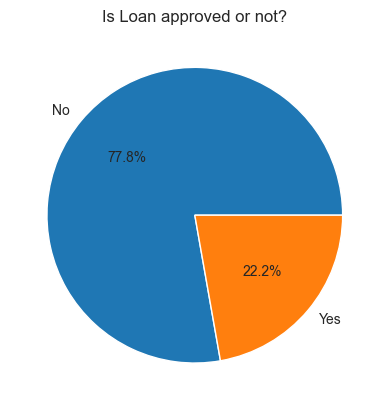

In [18]:
classes_count = dataset["loan_status"].value_counts()

plt.pie(classes_count, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("Is Loan approved or not?")

# Exploratory Data Analysis (EDA)

[Text(0, 0, '24841'), Text(0, 0, '20159')]

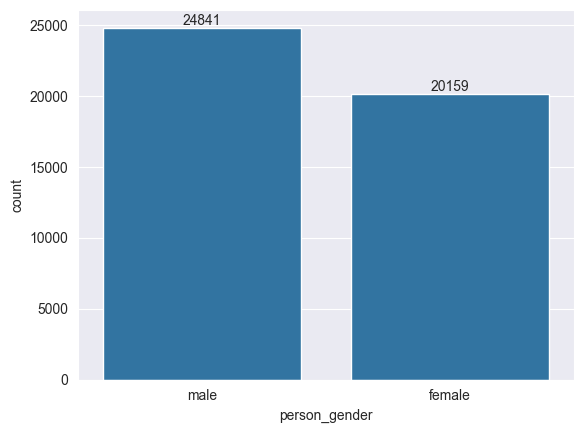

In [19]:


gender_cnt = dataset["person_gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])



[Text(0, 0, '13399'),
 Text(0, 0, '12028'),
 Text(0, 0, '11972'),
 Text(0, 0, '6980'),
 Text(0, 0, '621')]

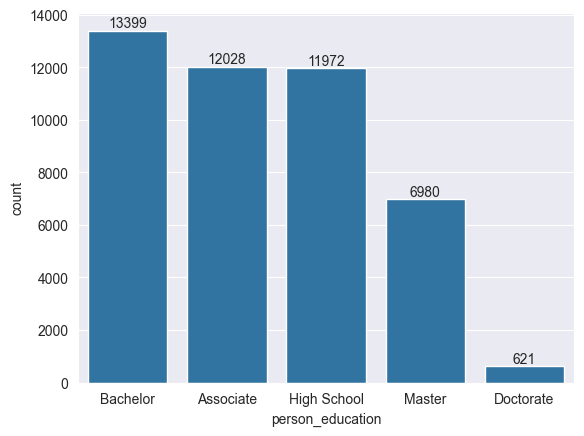

In [20]:
edu_cnt = dataset["person_education"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='person_annual_income', ylabel='Count'>

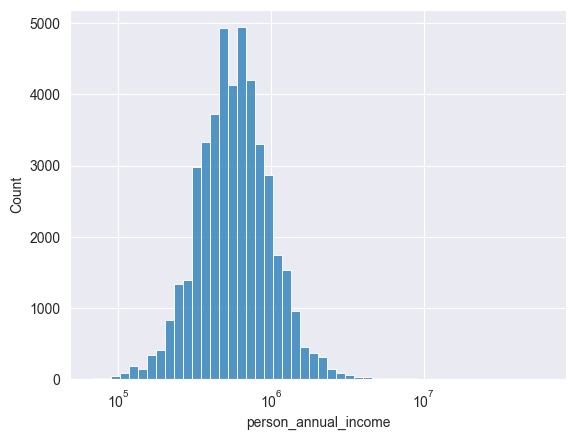

In [21]:
#analyze income

sns.histplot(
    data = dataset,
    x = 'person_annual_income',
    bins = 50,
    log_scale=True   
)

In [22]:
dataset['person_annual_income'].describe()

count    4.500000e+04
mean     6.827120e+05
std      6.835912e+05
min      6.800000e+04
25%      4.012340e+05
50%      5.699080e+05
75%      8.142086e+05
max      6.120651e+07
Name: person_annual_income, dtype: float64

<Axes: xlabel='loan_status', ylabel='person_annual_income'>

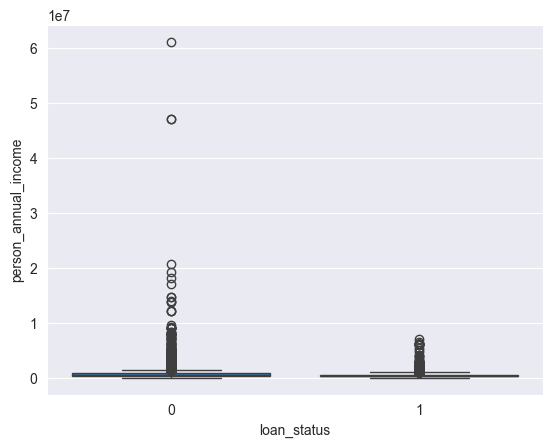

In [23]:
# outliers - box plots

sns.boxplot(
    data=dataset,
    x="loan_status",
    y="person_annual_income"
)

<Axes: xlabel='credit_score', ylabel='Count'>

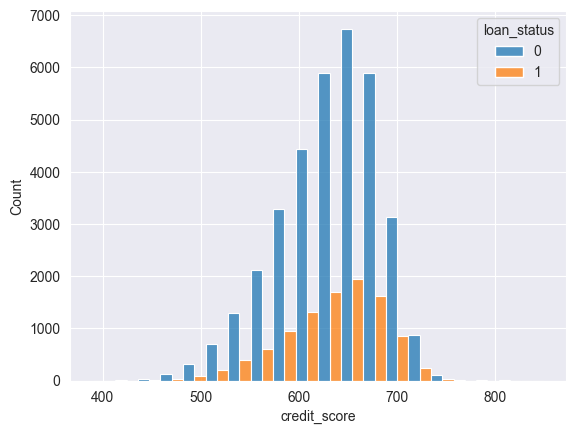

In [24]:
# Credit Score with Loan Approved
sns.histplot(
    data=dataset,
    x="credit_score",
    hue="loan_status",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='person_annual_income', ylabel='Count'>

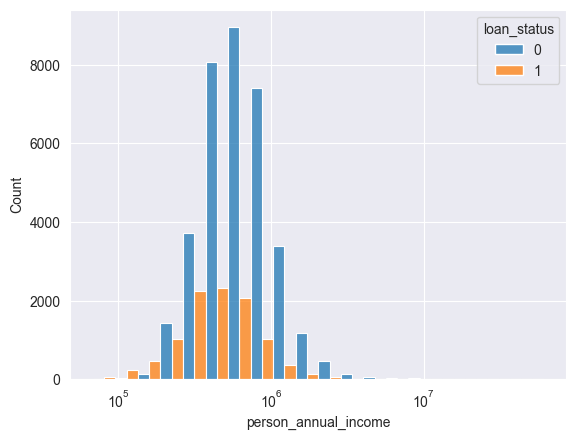

In [25]:
sns.histplot(
    data=dataset,
    x="person_annual_income",
    hue="loan_status",
    bins=20,
    multiple="dodge",
    log_scale=True
)

In [26]:
dataset['person_home_ownership'].value_counts()

person_home_ownership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64

In [27]:
dataset['person_home_ownership'] = dataset['person_home_ownership'].map({"RENT": 1,
"MORTGAGE":2,
"OWN" : 3,
"OTHER" :4})

In [28]:
dataset['loan_intent'].value_counts()

loan_intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

In [29]:
dataset['loan_intent'] = dataset['loan_intent'] .map({"EDUCATION" : 1,
"MEDICAL" : 2,         
"VENTURE" : 3,          
"PERSONAL" : 4,         
"DEBTCONSOLIDATION" : 5,
"HOMEIMPROVEMENT" : 6 })

In [30]:
dataset['previous_loan_defaults_on_file'].value_counts()

previous_loan_defaults_on_file
Yes    22858
No     22142
Name: count, dtype: int64

In [31]:
dataset['previous_loan_defaults_on_file'] = dataset['previous_loan_defaults_on_file'].map({"Yes": 1, "No":0})

In [32]:
dataset['person_gender'].value_counts()

person_gender
male      24841
female    20159
Name: count, dtype: int64

In [33]:
dataset['person_gender'] = dataset['person_gender'].map({"male": 1, "female":0})

In [34]:
dataset['person_education'].value_counts()

person_education
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: count, dtype: int64

In [35]:
dataset['person_education'] = dataset['person_education'].map({"Bachelor" : 1,
"Associate" : 2,
"High School" : 3,
"Master" : 4,
"Doctorate" : 5})

In [36]:
# from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# le = LabelEncoder()
# dataset["person_home_ownership"] = le.fit_transform(dataset["person_home_ownership"])

# It will encode from 0

In [37]:
dataset.head()

,person_age,person_gender,person_education,person_annual_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,0,4,611558.0,0,1,385000,4,16.02,3,561,0,1
1,21,0,3,104397.0,0,3,11000,1,11.14,2,504,1,0
2,25,0,3,105723.0,3,2,60500,2,12.87,3,635,0,1
3,23,0,1,677900.5,0,1,385000,2,15.23,2,675,0,1
4,24,1,4,562147.5,1,1,385000,2,14.27,4,586,0,1


# correlation heatmap

<Axes: >

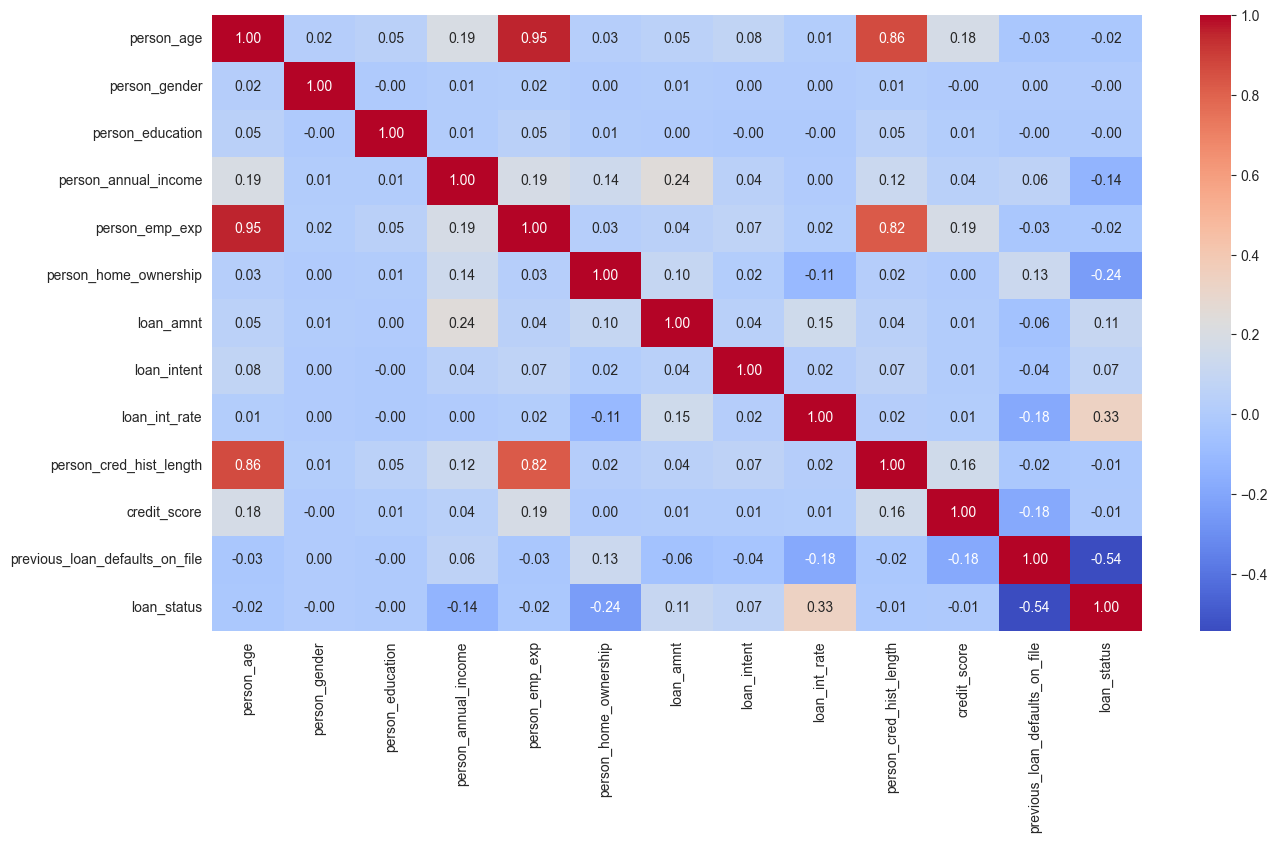

In [38]:
num_cols = dataset.select_dtypes(include="number")
corr_matrix = num_cols.corr()

plt.figure(figsize=(15, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

In [39]:
num_cols.corr()["loan_status"].sort_values(ascending=False)

loan_status                       1.000000
loan_int_rate                     0.332005
loan_amnt                         0.107714
loan_intent                       0.066898
person_gender                    -0.000561
person_education                 -0.003996
credit_score                     -0.007647
person_cred_hist_length          -0.014851
person_emp_exp                   -0.020481
person_age                       -0.021476
person_annual_income             -0.135808
person_home_ownership            -0.237779
previous_loan_defaults_on_file   -0.543096
Name: loan_status, dtype: float64

# Spliting

In [40]:
X = dataset.iloc[:,:-1]
Y = dataset.iloc[:,-1]

In [41]:
Y.head()

0    1
1    0
2    1
3    1
4    1
Name: loan_status, dtype: int64

In [42]:
from sklearn.model_selection import train_test_split,GridSearchCV

In [43]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [44]:
x_test.head()

,person_age,person_gender,person_education,person_annual_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,person_cred_hist_length,credit_score,previous_loan_defaults_on_file
37979,32,1,2,823352.5,10,2,82500,1,6.04,10,601,0
9911,24,1,2,483123.0,6,1,99000,1,11.49,4,647,1
43386,22,0,4,317033.0,0,1,55000,2,14.88,4,711,0
13822,23,0,1,339524.0,1,3,55000,3,13.99,3,597,1
44810,42,1,3,577779.0,20,2,110000,6,15.41,11,586,0


In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [46]:
x_train_scaled

array([[ 1.03947529, -1.10659687, -1.19808532, ...,  0.81673169,
        -0.03244403, -1.01415574],
       [-0.4561859 ,  0.90367145,  0.61926063, ..., -0.47891374,
         0.52468678,  0.98604185],
       [ 2.20276733, -1.10659687,  1.52793361, ...,  1.33498986,
         1.00222747,  0.98604185],
       ...,
       [ 0.87329072, -1.10659687, -0.28941234, ...,  0.81673169,
         0.38540408,  0.98604185],
       [-0.29000132,  0.90367145,  1.52793361, ..., -0.73804283,
        -0.5696773 , -1.01415574],
       [-0.29000132, -1.10659687,  0.61926063, ..., -0.73804283,
         0.62417442,  0.98604185]], shape=(36000, 12))

In [47]:
# Logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(x_train_scaled, y_train)

y_pred = log_model.predict(x_test_scaled)

# Evaluation
print("Logistic Regression Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Logistic Regression Model
Precision:  0.7411167512690355
Recall:  0.7263681592039801
F1 score:  0.7336683417085427
Accuracy:  0.8822222222222222
CM:  [[6480  510]
 [ 550 1460]]


In [48]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled, y_train)

y_pred = knn_model.predict(x_test_scaled)

# Evaluation
print("KNN Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

KNN Model
Precision:  0.732463295269168
Recall:  0.6701492537313433
F1 score:  0.6999220576773187
Accuracy:  0.8716666666666667
CM:  [[6498  492]
 [ 663 1347]]


In [49]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(x_train_scaled, y_train)

y_pred = nb_model.predict(x_test_scaled)

# Evaluation
print("Naive Bayes Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))


Naive Bayes Model
Precision:  0.4587723316536876
Recall:  0.9965174129353234
F1 score:  0.6282936010037641
Accuracy:  0.7366666666666667
CM:  [[4627 2363]
 [   7 2003]]


In [50]:
from sklearn.ensemble import RandomForestClassifier

rfc=RandomForestClassifier()
rfc.fit(x_train_scaled,y_train)

y_pred = rfc.predict(x_test_scaled)

# Evaluation
print("Random Forest Classifier Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Random Forest Classifier Model
Precision:  0.8715953307392996
Recall:  0.7800995024875622
F1 score:  0.8233132055657653
Accuracy:  0.9252222222222222
CM:  [[6759  231]
 [ 442 1568]]


In [ ]:
param_grid_rf = {'n_estimators': [10,20],
                 'max_features': [None, 'sqrt', 'log2'],
                 'max_depth': [None, 5, 6],
                 'criterion': ['gini', 'entropy'],
                 'min_samples_split': [2, 5],
                 'min_samples_leaf': [1, 2, 4]}

grid=GridSearchCV(rfc,param_grid_rf,refit=True,n_jobs=-1)
grid.fit(x_train_scaled, y_train)

In [52]:
grid.best_params_

{'criterion': 'entropy',
 'max_depth': None,
 'max_features': None,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'n_estimators': 20}

In [53]:
y_pred = grid.predict(x_test_scaled)

# Evaluation
print("After Hyper Parameter Tuning : ")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

After Hyper Parameter Tuning : 
Precision:  0.8770856507230256
Recall:  0.7845771144278607
F1 score:  0.8282563025210085
Accuracy:  0.9273333333333333
CM:  [[6769  221]
 [ 433 1577]]


In [54]:
categorical_features = [
    'person_gender', 'person_education', 'person_home_ownership', 
    'loan_intent', 'previous_loan_defaults_on_file'
]

numerical_features = [
    'person_age', 'person_annual_income', 'person_emp_exp', 'loan_amnt', 
    'loan_int_rate',  'person_cred_hist_length', 
    'credit_score'
]

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())  # Important for algorithms like KNN/SVM, good practice generally
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')) 
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rfc)
])

param_grid = {
    'classifier__n_estimators': [10, 20],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(clf_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

print("Training the pipeline...")
grid_search.fit(x_train, y_train)

Training the pipeline...


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [10, 20]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

In [56]:
y_pred = grid_search.predict(x_test)

In [57]:
x_test

,person_age,person_gender,person_education,person_annual_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,person_cred_hist_length,credit_score,previous_loan_defaults_on_file
37979,32,1,2,823352.5,10,2,82500,1,6.04,10,601,0
9911,24,1,2,483123.0,6,1,99000,1,11.49,4,647,1
43386,22,0,4,317033.0,0,1,55000,2,14.88,4,711,0
13822,23,0,1,339524.0,1,3,55000,3,13.99,3,597,1
44810,42,1,3,577779.0,20,2,110000,6,15.41,11,586,0
...,...,...,...,...,...,...,...,...,...,...,...,...
14572,21,1,1,1132242.5,0,2,154000,3,9.99,2,654,0
30384,39,1,3,526056.5,17,1,73975,1,16.45,11,606,1
36665,24,0,4,671075.0,1,1,154000,1,11.65,3,614,0
30569,38,1,2,315707.0,16,1,88000,2,11.01,14,695,0


In [58]:
from sklearn.metrics import classification_report,confusion_matrix
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      6990
           1       0.85      0.79      0.82      2010

    accuracy                           0.92      9000
   macro avg       0.90      0.87      0.88      9000
weighted avg       0.92      0.92      0.92      9000

Confusion Matrix:
[[6713  277]
 [ 432 1578]]


# Random Forest Classifier is having best Precision

# Pickling

In [59]:
import pickle 

In [60]:
pickle.dump(grid_search, open("model.pkl", "wb"))


In [61]:
dataset['loan_amnt'].describe()

count     45000.000000
mean     105414.733111
std       69463.753596
min        5500.000000
25%       55000.000000
50%       88000.000000
75%      134609.750000
max      385000.000000
Name: loan_amnt, dtype: float64